# Seasonal Agriculture Performance Analysis

**Major Project — VOIS AICTE Batch 2026-2027**

### Name :- Payal Pravin Thombare

A complete, data-driven analytics dashboard project analyzing how agricultural
performance varies across seasons, regions, crops, and farming practices.

## 1. Project Overview

This project analyzes a real agricultural dataset covering 4,000 farm records
across 8 Indian states, 8 crops, 3 growing seasons (Kharif, Rabi, Zaid), and 4
irrigation methods. The workflow follows a standard data-analytics pipeline —
**raw data → cleaning → analysis → KPIs → visualization → dashboard → insights →
recommendations** — and every number in this notebook is calculated directly
from the provided dataset. Nothing is hard-coded or fabricated.

## 2. Problem Statement

Agricultural activity is shaped by seasonal shifts in environmental conditions,
farming practices, resource availability, and market conditions, so performance
can differ considerably from one season to the next. Raw farm-level data alone
does not make these seasonal differences obvious. This project analyzes the
provided agricultural dataset to uncover meaningful seasonal patterns, trends,
relationships, and variations in agricultural performance.

## 3. Objectives

- Explore and understand the structure and quality of the dataset.
- Clean and prepare the data so it is reliable for analysis.
- Examine how yield, production, and profitability vary across seasons.
- Identify seasonal patterns and statistically test whether they are real.
- Investigate relationships between environmental/resource conditions and
  agricultural outcomes.
- Compare performance across regions, crops, and irrigation methods.
- Build a KPI-driven analytics dashboard summarizing the strongest findings.
- Translate findings into evidence-based recommendations for seasonal
  agricultural planning.

## 4. Technology Stack

| Layer | Tool |
|---|---|
| Language | Python 3 |
| Environment | Jupyter Notebook |
| Data processing | Pandas, NumPy |
| Visualization / Dashboard | Matplotlib, Seaborn |
| Statistical analysis | SciPy |

No other libraries or BI tools (e.g. Power BI) are used — the entire pipeline,
including the dashboard, is built in this notebook with the stack above.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# Resolve paths so the notebook runs whether launched from inside notebooks/
# (the normal case) or from the project root.
DATA_DIR = "../data" if os.path.isdir("../data") else "data"
VIZ_DIR = "../visualizations" if os.path.isdir("../visualizations") else "visualizations"
os.makedirs(VIZ_DIR, exist_ok=True)
RAW_PATH = f"{DATA_DIR}/agriculture_dataset.csv"
CLEAN_PATH = f"{DATA_DIR}/agriculture_dataset_cleaned.csv"

# ---- Consistent dashboard styling used throughout the notebook -------------
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10.5,
    'axes.titlesize': 12.5,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10.5,
    'axes.edgecolor': '#4A4A4A',
    'axes.grid': True,
    'grid.color': '#E3E6E3',
    'grid.linewidth': 0.7,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'legend.frameon': False,
    'text.color': '#1B2631',
    'axes.labelcolor': '#1B2631',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
})
sns.set_style('whitegrid', {'grid.color': '#E3E6E3'})

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
COLOR_SEASON = {'Kharif': '#2E7D32', 'Rabi': '#1565C0', 'Zaid': '#EF6C00'}
COLOR_PRIMARY   = '#2E7D32'
COLOR_SECONDARY = '#F9A825'
COLOR_NEGATIVE  = '#C62828'
COLOR_NEUTRAL   = '#607D8B'
COLOR_ACCENT    = '#0277BD'

print("Environment ready.")
print(f"Data directory: {DATA_DIR}")
print(f"Visualizations directory: {VIZ_DIR}")

Environment ready.
Data directory: ../data
Visualizations directory: ../visualizations


## 5. Dataset Overview

The dataset must be inspected before any design decisions are made — no
column, category, or relationship is assumed in advance.

In [2]:
df_raw = pd.read_csv(RAW_PATH)

print("Shape (rows, columns):", df_raw.shape)
print()
print("Column names and data types:")
print(df_raw.dtypes.to_string())
print()
print("First 5 records:")
print(df_raw.head().to_string())

Shape (rows, columns): (4000, 28)

Column names and data types:
Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                    

In [3]:
numeric_cols_raw = df_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_raw = df_raw.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(numeric_cols_raw)}):")
print(numeric_cols_raw)
print()
print(f"Categorical columns ({len(categorical_cols_raw)}):")
print(categorical_cols_raw)
print()
print("Key dimensions available in this dataset:")
print(" - Geographic : State, District")
print(" - Seasonal   : Season (Kharif / Rabi / Zaid)")
print(" - Crop       : Crop, Irrigation_Method")
print(" - Environment: Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, Soil_Moisture_pct")
print(" - Resources  : Nitrogen/Phosphorus/Potassium_kg_ha, Fertilizer_kg_ha, Pesticide_Litre_ha, Water_Used_m3, Seed_Quality_Score")
print(" - Performance: Yield_Tonnes_Ha, Production_Tonnes, Disease_Pest_Risk_pct")
print(" - Economic   : Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, Profit_INR")

Numerical columns (22):
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns (6):
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Key dimensions available in this dataset:
 - Geographic : State, District
 - Seasonal   : Season (Kharif / Rabi / Zaid)
 - Crop       : Crop, Irrigation_Method
 - Environment: Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, Soil_Moisture_pct
 - Resources  : Nitrogen/Phosphorus/Potassium_kg_ha, Fertilizer_kg_ha, Pesticide_Litre_ha, Water_Used_m3, Seed_Quality_Score
 - Performance: Yield_Tonnes_Ha, Production_T

## 6. Data Quality Assessment

Checking missing values, duplicate records, unique categories, numerical
ranges, and any suspicious values before deciding how to clean the data.

In [4]:
print("=== MISSING VALUES ===")
missing = df_raw.isnull().sum()
missing = missing[missing > 0]
print(missing.to_string())
print(f"\nTotal missing cells: {missing.sum()} out of {df_raw.size} ({missing.sum()/df_raw.size*100:.2f}%)")

print("\n=== DUPLICATE RECORDS ===")
print("Fully duplicated rows:", df_raw.duplicated().sum())
print("Duplicate Farm_ID values:", df_raw['Farm_ID'].duplicated().sum())

=== MISSING VALUES ===
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32

Total missing cells: 120 out of 112000 (0.11%)

=== DUPLICATE RECORDS ===
Fully duplicated rows: 0
Duplicate Farm_ID values: 0


In [5]:
print("=== CATEGORICAL COLUMNS: UNIQUE VALUES ===\n")
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    vc = df_raw[col].value_counts()
    print(f"{col} — {df_raw[col].nunique()} categories:")
    print(vc.to_string())
    print()

=== CATEGORICAL COLUMNS: UNIQUE VALUES ===

State — 8 categories:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484

District — 10 categories:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371

Crop — 8 categories:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305

Season — 3 categories:
Season
Kharif    1779
Rabi      1627
Zaid       594

Irrigation_Method — 4 categories:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734



In [6]:
print("=== NUMERICAL SUMMARY (raw data) ===")
print(df_raw.describe().T.round(2).to_string())

=== NUMERICAL SUMMARY (raw data) ===
                                count       mean        std         min        25%        50%        75%         max
Farm_Area_Hectares             4000.0       7.89       4.22        0.50       4.26       7.90      11.65       15.00
Rainfall_mm                    3952.0     601.15     288.93       80.00     370.20     582.00     834.95     1395.20
Avg_Temperature_C              4000.0      26.82       3.82       16.20      23.90      26.90      29.60       39.70
Humidity_pct                   4000.0      63.21      11.96       25.00      54.78      63.00      71.90       95.00
Sunlight_Hours_Day             4000.0       7.32       1.12        3.50       6.60       7.30       8.10       11.00
Soil_pH                        4000.0       6.70       0.64        5.20       6.26       6.69       7.14        8.40
Soil_Moisture_pct              3960.0      26.51       6.71        8.00      21.70      26.40      31.30       47.00
Nitrogen_kg_ha             

In [7]:
print("=== OUTLIER CHECK: Yield_Tonnes_Ha looks extremely wide (0.3 to 101.4) ===")
print(df_raw.groupby('Crop')['Yield_Tonnes_Ha'].agg(['count', 'mean', 'median', 'max']).round(2).to_string())
print()
print("Finding: the wide range is entirely explained by crop type. Sugarcane genuinely")
print("yields 40-100+ tonnes/hectare, versus under 6 t/ha for every other crop in this")
print("dataset — this matches real-world agronomy, not a data-entry error. These values")
print("are therefore KEPT. To stop Sugarcane's scale from distorting cross-crop or")
print("cross-season comparisons, later sections use log-transforms, exclude Sugarcane")
print("where explicitly noted, or compare crops on their own axis.")

print("\n=== CONSISTENCY CHECK: are the derived economic/efficiency columns internally consistent? ===")
chk = df_raw.copy()
chk['revenue_check'] = (chk['Production_Tonnes'] * chk['Market_Price_INR_Tonne'] - chk['Revenue_INR']).abs()
chk['profit_check']  = (chk['Revenue_INR'] - chk['Total_Cost_INR'] - chk['Profit_INR']).abs()
print("Max |Revenue - Production*Price| :", chk['revenue_check'].max())
print("Max |Profit - (Revenue - Cost)|  :", chk['profit_check'].max())
print("-> Both are ~0, confirming Revenue, Cost, and Profit are internally consistent.")

=== OUTLIER CHECK: Yield_Tonnes_Ha looks extremely wide (0.3 to 101.4) ===
           count   mean  median     max
Crop                                   
Chilli       407   1.54    1.56    3.90
Cotton       504   1.23    1.24    2.90
Groundnut    419   1.32    1.40    3.02
Maize        547   2.72    2.85    6.08
Pulses       494   0.92    0.94    2.09
Rice         682   2.44    2.46    5.70
Sugarcane    303  46.94   48.03  101.44
Wheat        612   2.11    2.22    4.56

Finding: the wide range is entirely explained by crop type. Sugarcane genuinely
yields 40-100+ tonnes/hectare, versus under 6 t/ha for every other crop in this
dataset — this matches real-world agronomy, not a data-entry error. These values
are therefore KEPT. To stop Sugarcane's scale from distorting cross-crop or
cross-season comparisons, later sections use log-transforms, exclude Sugarcane
where explicitly noted, or compare crops on their own axis.

=== CONSISTENCY CHECK: are the derived economic/efficiency columns 

## 7. Data Cleaning

Three columns have missing values: `Yield_Tonnes_Ha` (32), `Rainfall_mm` (48),
and `Soil_Moisture_pct` (40). Each is handled differently, based on what the
data itself supports — not a single blanket rule.

In [8]:
df = df_raw.copy()

# --- Yield_Tonnes_Ha: derive exactly, don't statistically impute -------------
# Production_Tonnes = Yield_Tonnes_Ha * Farm_Area_Hectares holds almost exactly
# for every complete row, so for the 32 rows missing Yield we can reconstruct it
# from Production and Area rather than guessing with a group average.
complete = df.dropna(subset=['Yield_Tonnes_Ha']).copy()
ratio = complete['Production_Tonnes'] / (complete['Yield_Tonnes_Ha'] * complete['Farm_Area_Hectares'])
print(f"Validation on {len(complete)} complete rows — Production/(Yield*Area) ratio: "
      f"mean={ratio.mean():.4f}, std={ratio.std():.4f} (both ~1.000, confirms the relationship holds)")

before = int(df['Yield_Tonnes_Ha'].isnull().sum())
missing_mask = df['Yield_Tonnes_Ha'].isnull()
df.loc[missing_mask, 'Yield_Tonnes_Ha'] = (
    df.loc[missing_mask, 'Production_Tonnes'] / df.loc[missing_mask, 'Farm_Area_Hectares']
)
print(f"Yield_Tonnes_Ha: derived {before} missing values from Production_Tonnes / Farm_Area_Hectares")

# --- Rainfall_mm & Soil_Moisture_pct: season-wise median imputation ----------
# Both vary strongly and logically by season (see below), so imputing within
# each season preserves that structure instead of pulling values toward one
# overall average.
print()
print("Season averages that justify season-wise (not overall) imputation:")
print(df.groupby('Season')[['Rainfall_mm', 'Soil_Moisture_pct']].mean().round(1).to_string())
print()

for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    before = int(df[col].isnull().sum())
    df[col] = df.groupby('Season')[col].transform(lambda s: s.fillna(s.median()))
    print(f"{col}: imputed {before} missing values using each row's season median")

# --- Final validation ---------------------------------------------------------
print()
print("Remaining missing values:", int(df.isnull().sum().sum()))
print("Remaining duplicate rows:", int(df.duplicated().sum()))
print("Cleaned dataset shape   :", df.shape)

df.to_csv(CLEAN_PATH, index=False)
print(f"\nCleaned dataset saved to: {CLEAN_PATH}")

Validation on 3968 complete rows — Production/(Yield*Area) ratio: mean=1.0000, std=0.0013 (both ~1.000, confirms the relationship holds)
Yield_Tonnes_Ha: derived 32 missing values from Production_Tonnes / Farm_Area_Hectares

Season averages that justify season-wise (not overall) imputation:
        Rainfall_mm  Soil_Moisture_pct
Season                                
Kharif        852.1               31.2
Rabi          436.0               24.1
Zaid          299.4               19.2

Rainfall_mm: imputed 48 missing values using each row's season median
Soil_Moisture_pct: imputed 40 missing values using each row's season median

Remaining missing values: 0
Remaining duplicate rows: 0
Cleaned dataset shape   : (4000, 28)

Cleaned dataset saved to: ../data/agriculture_dataset_cleaned.csv


All further analysis in this notebook uses the **cleaned** dataset (`df`), not
the raw one.

## 8. Exploratory Data Analysis

A broad look at distributions and relationships before drilling into seasonal,
environmental, resource, economic, and regional questions specifically.

In [9]:
key_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
print("Descriptive statistics — core performance & economic metrics:")
print(df[key_cols].describe().round(2).to_string())

Descriptive statistics — core performance & economic metrics:
       Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Total_Cost_INR  Profit_INR
count          4000.00            4000.00      4000.00         4000.00     4000.00
mean              5.26              43.25    637860.05       526303.58   111556.46
std              13.34             126.88    636974.71       294419.14   545081.89
min               0.30               0.15      6107.00        26826.00 -1019223.00
25%               1.05               5.02    207517.25       274577.50  -148731.75
50%               1.74              11.77    456830.50       519082.50     3673.00
75%               2.84              24.36    836874.75       761996.50   216187.75
max             101.44            1424.40   5080900.00      1349990.00  4345421.00


Share of farms operating at a loss (Profit < 0): 49.1%


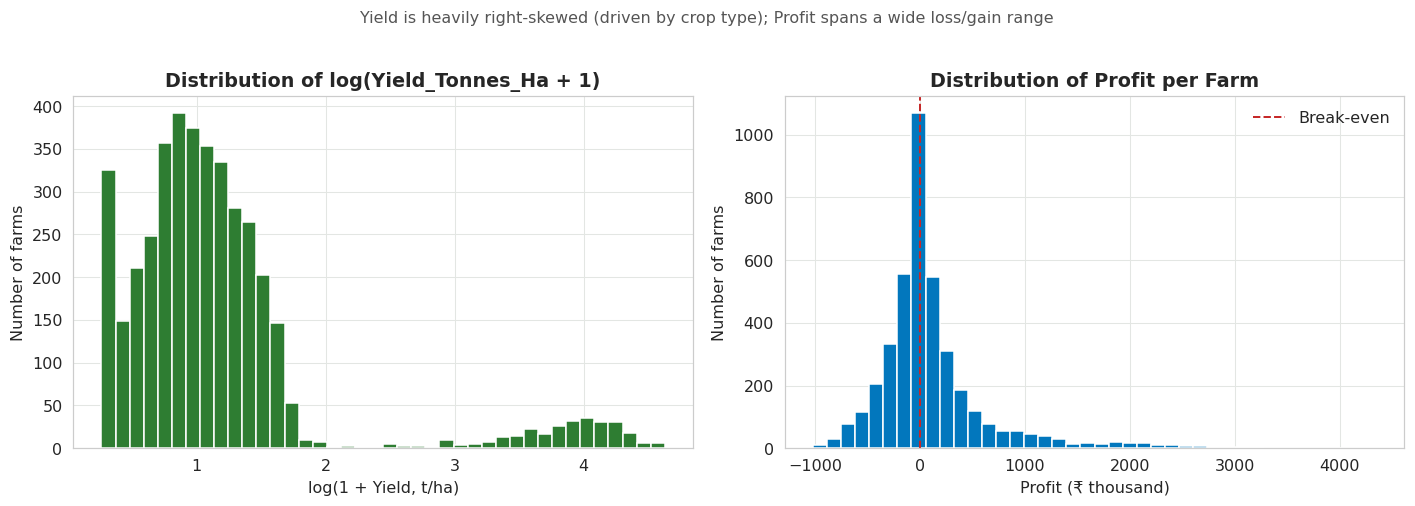

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(np.log1p(df['Yield_Tonnes_Ha']), bins=40, color=COLOR_PRIMARY, edgecolor='white')
axes[0].set_title('Distribution of log(Yield_Tonnes_Ha + 1)')
axes[0].set_xlabel('log(1 + Yield, t/ha)')
axes[0].set_ylabel('Number of farms')

axes[1].hist(df['Profit_INR']/1000, bins=40, color=COLOR_ACCENT, edgecolor='white')
axes[1].axvline(0, color=COLOR_NEGATIVE, linestyle='--', linewidth=1.3, label='Break-even')
axes[1].set_title('Distribution of Profit per Farm')
axes[1].set_xlabel('Profit (₹ thousand)')
axes[1].set_ylabel('Number of farms')
axes[1].legend()

plt.suptitle('Yield is heavily right-skewed (driven by crop type); Profit spans a wide loss/gain range',
             fontsize=10.5, y=1.02, color='#555555')
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/01_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Share of farms operating at a loss (Profit < 0): {(df['Profit_INR']<0).mean()*100:.1f}%")

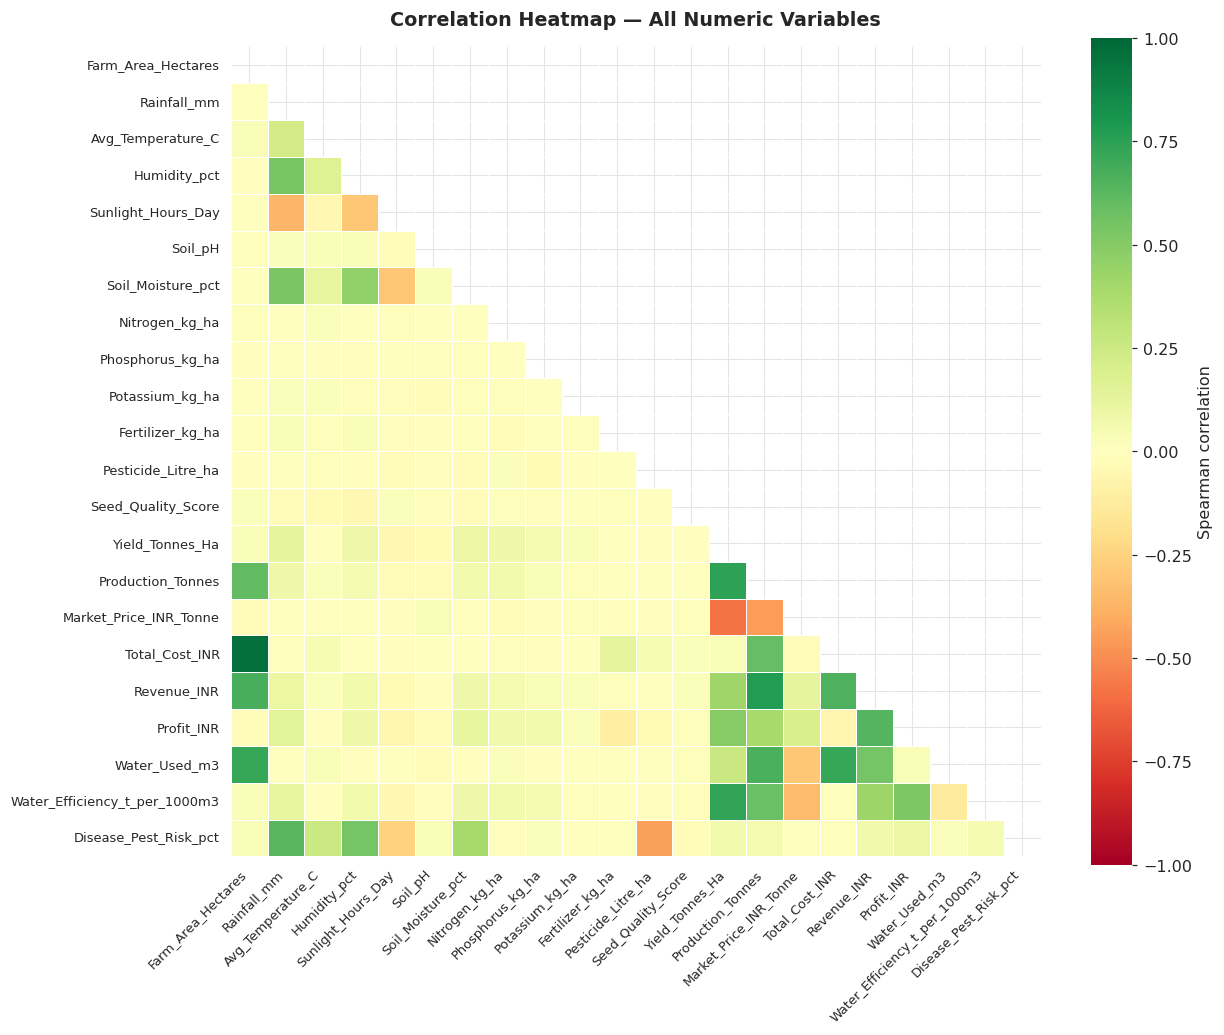

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11.5, 9.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0, vmin=-1, vmax=1, linewidths=0.4,
            cbar_kws={'label': 'Spearman correlation'}, ax=ax, square=True)
ax.set_title('Correlation Heatmap — All Numeric Variables', fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right', fontsize=8.5)
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/02_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Seasonal Analysis

The central question of this project: **how does agricultural performance
change across Kharif, Rabi, and Zaid?**

In [12]:
print("Average Yield_Tonnes_Ha by season (raw, all crops):")
print(df.groupby('Season')['Yield_Tonnes_Ha'].mean().reindex(SEASON_ORDER).round(2).to_string())
print()
print("Average Yield_Tonnes_Ha by season, EXCLUDING Sugarcane (removes the crop-scale effect):")
yield_ex_sugar = df[df['Crop'] != 'Sugarcane'].groupby('Season')['Yield_Tonnes_Ha'].mean().reindex(SEASON_ORDER)
print(yield_ex_sugar.round(2).to_string())
print()
print("Mean Yield by Crop x Season — is the seasonal pattern consistent within every crop?")
yield_by_crop_season = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()[SEASON_ORDER]
print(yield_by_crop_season.round(2).to_string())
consistent = ((yield_by_crop_season['Kharif'] > yield_by_crop_season['Rabi']) &
              (yield_by_crop_season['Rabi'] > yield_by_crop_season['Zaid'])).sum()
print(f"\n-> Kharif > Rabi > Zaid holds for {consistent} out of {len(yield_by_crop_season)} crops.")

Average Yield_Tonnes_Ha by season (raw, all crops):
Season
Kharif    5.63
Rabi      5.09
Zaid      4.63

Average Yield_Tonnes_Ha by season, EXCLUDING Sugarcane (removes the crop-scale effect):
Season
Kharif    2.01
Rabi      1.75
Zaid      1.46

Mean Yield by Crop x Season — is the seasonal pattern consistent within every crop?
Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.46   1.18
Cotton       1.37   1.19   0.94
Groundnut    1.48   1.23   1.04
Maize        2.97   2.62   2.28
Pulses       1.04   0.87   0.65
Rice         2.71   2.33   1.90
Sugarcane   53.46  43.95  38.42
Wheat        2.25   2.06   1.75

-> Kharif > Rabi > Zaid holds for 8 out of 8 crops.


In [13]:
print("Average Profit_INR by season:")
profit_by_season = df.groupby('Season')['Profit_INR'].mean().reindex(SEASON_ORDER)
print(profit_by_season.round(0).to_string())
print()
print("Share of loss-making farms by season:")
loss_by_season = df.assign(is_loss=df['Profit_INR'] < 0).groupby('Season')['is_loss'].mean().reindex(SEASON_ORDER) * 100
print(loss_by_season.round(1).to_string())

Average Profit_INR by season:
Season
Kharif    178915.0
Rabi       87689.0
Zaid      -24805.0

Share of loss-making farms by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5


### Statistical test: is the seasonal difference in yield real, or just noise?

A plain ANOVA on raw yield is misleading here because Sugarcane's much larger
scale inflates the within-group variance. Testing on `log(Yield)` — standard
practice for a right-skewed measure — removes that scale effect.

In [14]:
groups_raw = [g['Yield_Tonnes_Ha'].values for _, g in df.groupby('Season')]
f_raw, p_raw = stats.f_oneway(*groups_raw)
print(f"ANOVA  Yield (raw)      ~ Season  ->  F={f_raw:.3f}, p={p_raw:.4f}   (not significant)")

groups_log = [np.log1p(g['Yield_Tonnes_Ha'].values) for _, g in df.groupby('Season')]
f_log, p_log = stats.f_oneway(*groups_log)
print(f"ANOVA  log(Yield)       ~ Season  ->  F={f_log:.3f}, p={p_log:.4g}   (significant)")

groups_profit = [g['Profit_INR'].values for _, g in df.groupby('Season')]
f_p, p_p = stats.f_oneway(*groups_profit)
print(f"ANOVA  Profit           ~ Season  ->  F={f_p:.3f}, p={p_p:.4g}   (significant)")

k = df.loc[df['Season'] == 'Kharif', 'Profit_INR']
z = df.loc[df['Season'] == 'Zaid', 'Profit_INR']
t_kz, p_kz = stats.ttest_ind(k, z, equal_var=False)
print(f"\nWelch t-test  Profit: Kharif vs Zaid  ->  t={t_kz:.3f}, p={p_kz:.4g}")
print(f"Kharif mean profit = ₹{k.mean():,.0f}   Zaid mean profit = ₹{z.mean():,.0f}   "
      f"diff = ₹{k.mean()-z.mean():,.0f}")

ANOVA  Yield (raw)      ~ Season  ->  F=1.463, p=0.2317   (not significant)
ANOVA  log(Yield)       ~ Season  ->  F=8.030, p=0.0003308   (significant)
ANOVA  Profit           ~ Season  ->  F=34.292, p=1.712e-15   (significant)

Welch t-test  Profit: Kharif vs Zaid  ->  t=8.843, p=2.711e-18
Kharif mean profit = ₹178,915   Zaid mean profit = ₹-24,805   diff = ₹203,719


### Seasonal Performance dashboard chart

Kharif → Rabi → Zaid is the natural order of India's agricultural calendar
(monsoon → winter → summer), so this chart reads left-to-right as one growing
year, not an arbitrary category order.

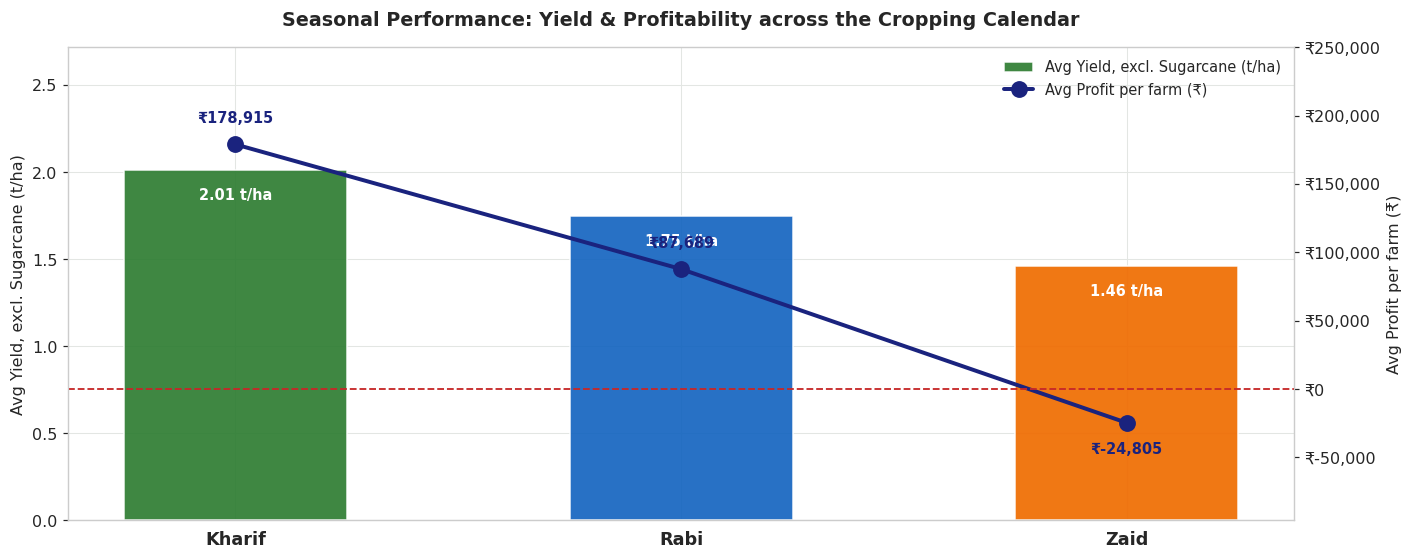

In [15]:
fig, ax1 = plt.subplots(figsize=(13, 5.2))
x = np.arange(len(SEASON_ORDER))

bars = ax1.bar(x, yield_ex_sugar.reindex(SEASON_ORDER).values, width=0.5,
                color=[COLOR_SEASON[s] for s in SEASON_ORDER], alpha=0.92,
                label='Avg Yield, excl. Sugarcane (t/ha)')
ax1.set_xticks(x)
ax1.set_xticklabels(SEASON_ORDER, fontsize=11.5, fontweight='bold')
ax1.set_ylabel('Avg Yield, excl. Sugarcane (t/ha)')
ax1.set_ylim(0, yield_ex_sugar.max()*1.35)
for i, v in enumerate(yield_ex_sugar.reindex(SEASON_ORDER).values):
    ax1.text(i, v - 0.10, f"{v:.2f} t/ha", ha='center', va='top', color='white',
              fontweight='bold', fontsize=9.5)

ax2 = ax1.twinx()
prof_vals = profit_by_season.reindex(SEASON_ORDER).values
ax2.plot(x, prof_vals, color='#1A237E', marker='o', markersize=10, linewidth=2.6,
         label='Avg Profit per farm (₹)')
ax2.axhline(0, color=COLOR_NEGATIVE, linestyle='--', linewidth=1.2)
ax2.set_ylabel('Avg Profit per farm (₹)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v:,.0f}'))
for i, v in enumerate(prof_vals):
    ax2.annotate(f"₹{v:,.0f}", (i, v), textcoords="offset points",
                 xytext=(0, 14 if v >= 0 else -20), ha='center', fontsize=9.5,
                 fontweight='bold', color='#1A237E')
pad = (prof_vals.max() - prof_vals.min()) * 0.35
ax2.set_ylim(prof_vals.min() - pad, prof_vals.max() + pad)
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9.5)

ax1.set_title('Seasonal Performance: Yield & Profitability across the Cropping Calendar', pad=14)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/03_seasonal_performance_main.png", dpi=150, bbox_inches='tight')
plt.show()

### Is the seasonal pattern the same for every crop?

Every crop scores 100 in Kharif by construction; every crop's Rabi and Zaid
figures fall below 100 — the Kharif > Rabi > Zaid pattern is universal, just
expressed on each crop's own scale so Sugarcane doesn't dominate the chart.


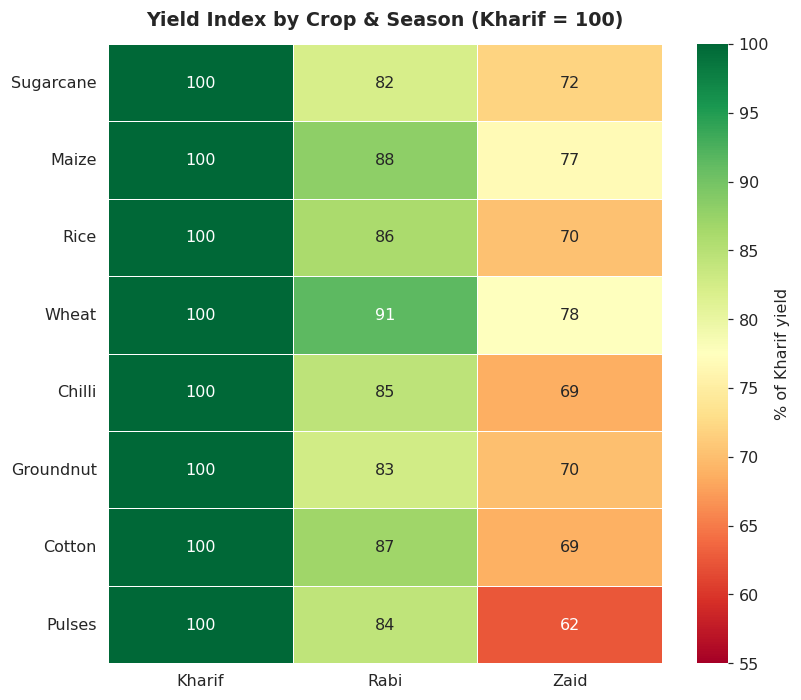

In [16]:
order_by_scale = yield_by_crop_season.mean(axis=1).sort_values(ascending=False).index
idx_table = yield_by_crop_season.div(yield_by_crop_season['Kharif'], axis=0) * 100
idx_table = idx_table.loc[order_by_scale]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(idx_table, annot=True, fmt='.0f', cmap='RdYlGn', vmin=55, vmax=100,
            linewidths=0.6, linecolor='white', cbar_kws={'label': '% of Kharif yield'}, ax=ax)
ax.set_title('Yield Index by Crop & Season (Kharif = 100)', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/04_yield_index_crop_season.png", dpi=150, bbox_inches='tight')
plt.show()
print("Every crop scores 100 in Kharif by construction; every crop's Rabi and Zaid")
print("figures fall below 100 — the Kharif > Rabi > Zaid pattern is universal, just")
print("expressed on each crop's own scale so Sugarcane doesn't dominate the chart.")

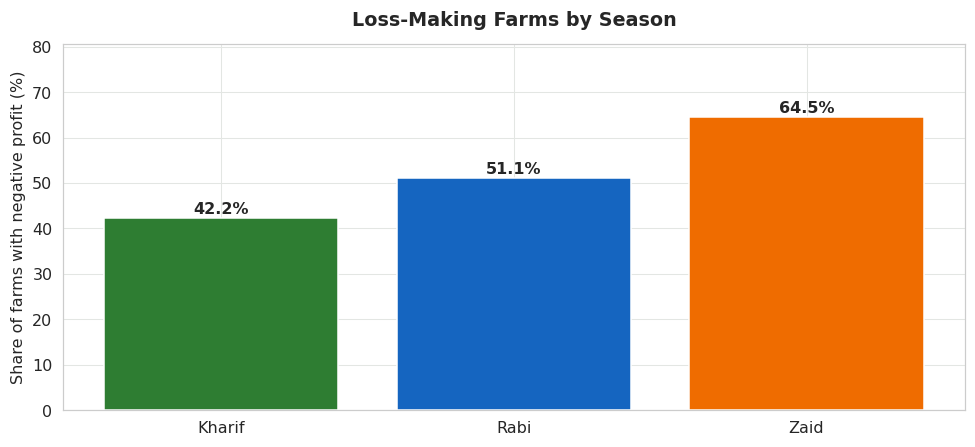

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(SEASON_ORDER, loss_by_season.reindex(SEASON_ORDER).values,
              color=[COLOR_SEASON[s] for s in SEASON_ORDER])
for i, v in enumerate(loss_by_season.reindex(SEASON_ORDER).values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
ax.set_ylabel('Share of farms with negative profit (%)')
ax.set_title('Loss-Making Farms by Season', pad=12)
ax.set_ylim(0, max(loss_by_season)*1.25)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/05_loss_rate_by_season.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Environmental Analysis

How do environmental conditions differ by season, and are they associated
with agricultural performance?

In [18]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
            'Soil_pH', 'Soil_Moisture_pct']
print("Environmental conditions by season (mean):")
print(df.groupby('Season')[env_cols].mean().reindex(SEASON_ORDER).round(2).to_string())

Environmental conditions by season (mean):
        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_pH  Soil_Moisture_pct
Season                                                                                              
Kharif       852.11              28.45         71.81                6.79     6.73              31.20
Rabi         435.94              23.49         57.89                7.59     6.67              24.05
Zaid         299.12              31.04         52.01                8.18     6.69              19.17


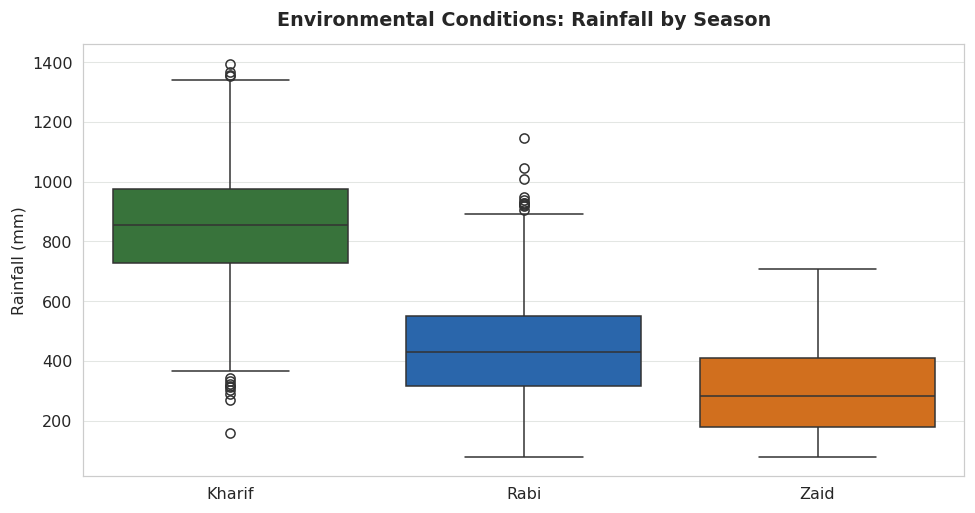

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=SEASON_ORDER,
            hue='Season', palette=COLOR_SEASON, legend=False, ax=ax)
ax.set_title('Environmental Conditions: Rainfall by Season', pad=12)
ax.set_ylabel('Rainfall (mm)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/06_rainfall_by_season.png", dpi=150, bbox_inches='tight')
plt.show()

### Relationship between environmental conditions and yield

Spearman correlation of environmental variables with Yield_Tonnes_Ha:
                    spearman_r  p_value
Rainfall_mm             0.1295   0.0000
Soil_Moisture_pct       0.0972   0.0000
Humidity_pct            0.0822   0.0000
Avg_Temperature_C       0.0019   0.9048
Soil_pH                -0.0318   0.0444
Sunlight_Hours_Day     -0.0521   0.0010
Rainfall and Soil Moisture show the clearest (positive, if modest) relationship
with yield among the environmental variables; Temperature, Soil pH and Sunlight
show almost no association in this dataset.


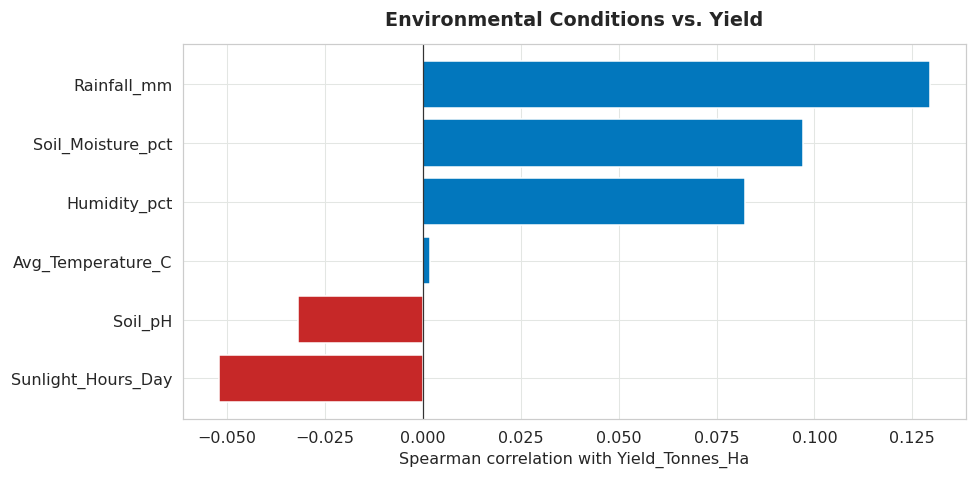

In [20]:
env_corr = {}
for c in env_cols:
    r, p = stats.spearmanr(df[c], df['Yield_Tonnes_Ha'])
    env_corr[c] = (r, p)
env_corr_df = pd.DataFrame(env_corr, index=['spearman_r', 'p_value']).T.sort_values('spearman_r', ascending=False)
print("Spearman correlation of environmental variables with Yield_Tonnes_Ha:")
print(env_corr_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
vals = env_corr_df['spearman_r']
colors = [COLOR_ACCENT if v >= 0 else COLOR_NEGATIVE for v in vals]
ax.barh(vals.index[::-1], vals.values[::-1], color=colors[::-1])
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_xlabel('Spearman correlation with Yield_Tonnes_Ha')
ax.set_title('Environmental Conditions vs. Yield', pad=12)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/07_environmental_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Rainfall and Soil Moisture show the clearest (positive, if modest) relationship")
print("with yield among the environmental variables; Temperature, Soil pH and Sunlight")
print("show almost no association in this dataset.")

## 11. Resource Usage Analysis

How do fertilizer, nutrients, water, and irrigation choice relate to
performance?

In [21]:
res_cols = ['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha',
            'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Water_Used_m3']
print("Average resource usage by season:")
print(df.groupby('Season')[res_cols].mean().reindex(SEASON_ORDER).round(2).to_string())

Average resource usage by season:
        Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha  Fertilizer_kg_ha  Pesticide_Litre_ha  Seed_Quality_Score  Water_Used_m3
Season                                                                                                                            
Kharif          120.02             58.10           105.30            187.08                5.08                0.82        6102.20
Rabi            120.40             57.31           103.93            185.41                5.02                0.83        5846.99
Zaid            120.53             58.13           105.42            184.64                5.17                0.82        6419.89


Spearman correlation of resource-usage variables with Yield_Tonnes_Ha:
                    spearman_r  p_value
Water_Used_m3           0.2644   0.0000
Nitrogen_kg_ha          0.0833   0.0000
Phosphorus_kg_ha        0.0480   0.0024
Potassium_kg_ha         0.0248   0.1167
Fertilizer_kg_ha        0.0016   0.9206
Seed_Quality_Score     -0.0000   0.9986
Pesticide_Litre_ha     -0.0005   0.9758


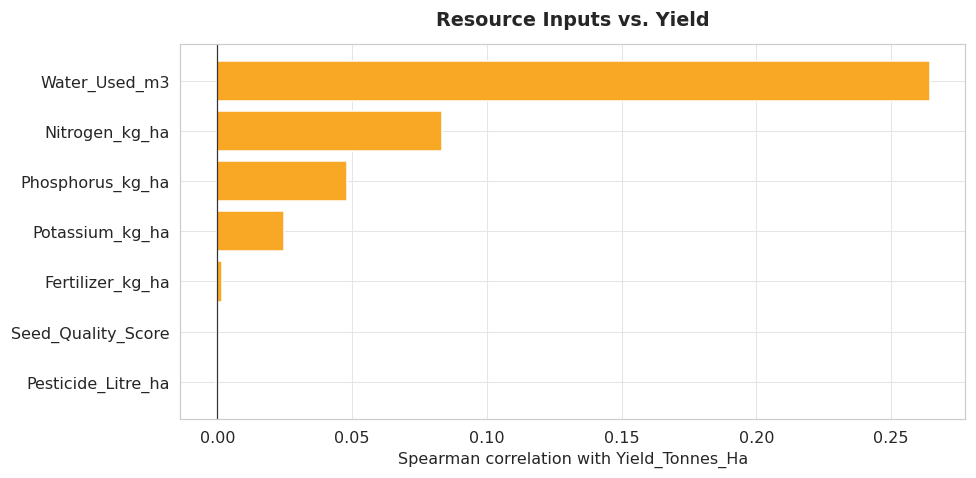

In [22]:
res_corr = {}
for c in res_cols:
    r, p = stats.spearmanr(df[c], df['Yield_Tonnes_Ha'])
    res_corr[c] = (r, p)
res_corr_df = pd.DataFrame(res_corr, index=['spearman_r', 'p_value']).T.sort_values('spearman_r', ascending=False)
print("Spearman correlation of resource-usage variables with Yield_Tonnes_Ha:")
print(res_corr_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
vals = res_corr_df['spearman_r']
colors = [COLOR_SECONDARY if v >= 0 else COLOR_NEGATIVE for v in vals]
ax.barh(vals.index[::-1], vals.values[::-1], color=colors[::-1])
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_xlabel('Spearman correlation with Yield_Tonnes_Ha')
ax.set_title('Resource Inputs vs. Yield', pad=12)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/08_resource_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print("Does Fertilizer_kg_ha relate to yield WITHIN each crop (i.e. once crop type is")
print("controlled for)? If fertilizer genuinely helped, we would expect a consistent")
print("positive correlation within crops too.\n")
within_crop = []
for crop, g in df.groupby('Crop'):
    r, p = stats.spearmanr(g['Fertilizer_kg_ha'], g['Yield_Tonnes_Ha'])
    within_crop.append({'Crop': crop, 'spearman_r': round(r, 3), 'p_value': round(p, 4)})
within_crop_df = pd.DataFrame(within_crop).sort_values('spearman_r')
print(within_crop_df.to_string(index=False))
print("\n-> Correlations are close to zero (or slightly negative) for every crop —")
print("fertilizer amount is not a meaningful yield driver in this dataset.")

Does Fertilizer_kg_ha relate to yield WITHIN each crop (i.e. once crop type is
controlled for)? If fertilizer genuinely helped, we would expect a consistent
positive correlation within crops too.

     Crop  spearman_r  p_value
   Chilli      -0.117   0.0178
     Rice      -0.023   0.5392
   Pulses      -0.017   0.6996
   Cotton      -0.016   0.7197
Groundnut      -0.006   0.9069
    Wheat       0.036   0.3794
Sugarcane       0.047   0.4167
    Maize       0.049   0.2533

-> Correlations are close to zero (or slightly negative) for every crop —
fertilizer amount is not a meaningful yield driver in this dataset.


### Irrigation method: water use, efficiency, yield and profit

In [24]:
irr_summary = df.groupby('Irrigation_Method')[
    ['Yield_Tonnes_Ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Profit_INR']
].mean().round(2)
print("Performance by irrigation method:")
print(irr_summary.sort_values('Profit_INR', ascending=False).to_string())

groups_irr = [np.log1p(g['Yield_Tonnes_Ha'].values) for _, g in df.groupby('Irrigation_Method')]
f_irr, p_irr = stats.f_oneway(*groups_irr)
print(f"\nANOVA  log(Yield)  ~ Irrigation_Method  ->  F={f_irr:.3f}, p={p_irr:.4g}")
groups_irr_p = [g['Profit_INR'].values for _, g in df.groupby('Irrigation_Method')]
f_irr_p, p_irr_p = stats.f_oneway(*groups_irr_p)
print(f"ANOVA  Profit      ~ Irrigation_Method  ->  F={f_irr_p:.3f}, p={p_irr_p:.4g}")

Performance by irrigation method:
                   Yield_Tonnes_Ha  Water_Used_m3  Water_Efficiency_t_per_1000m3  Profit_INR
Irrigation_Method                                                                           
Drip                          6.68        5918.75                           6.27   219626.00
Sprinkler                     5.16        6208.26                           4.67    91121.08
Rainfed                       4.60        3549.55                           7.56    79050.37
Flood                         4.86        8026.47                           3.44    73354.02

ANOVA  log(Yield)  ~ Irrigation_Method  ->  F=6.109, p=0.0003839
ANOVA  Profit      ~ Irrigation_Method  ->  F=15.887, p=2.877e-10


Flood irrigation uses the most water for the lowest efficiency and lowest profit;
Drip irrigation achieves the best yield and profit while using less water than Flood.


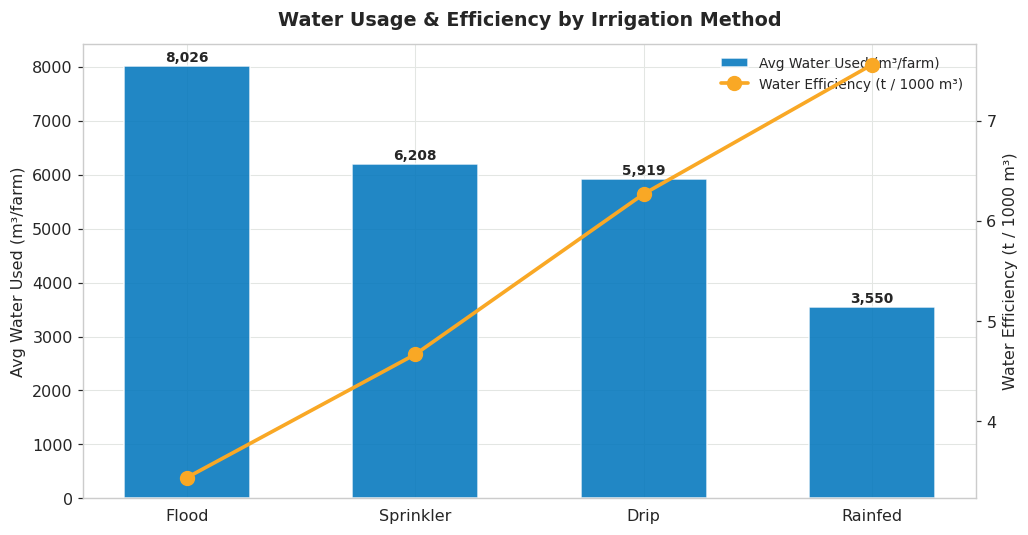

In [25]:
irr_order = irr_summary.sort_values('Water_Used_m3', ascending=False).index.tolist()
fig, ax1 = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(irr_order))
water = irr_summary.loc[irr_order, 'Water_Used_m3']
eff = irr_summary.loc[irr_order, 'Water_Efficiency_t_per_1000m3']

ax1.bar(x, water.values, width=0.55, color=COLOR_ACCENT, alpha=0.88, label='Avg Water Used (m³/farm)')
ax1.set_xticks(x)
ax1.set_xticklabels(irr_order, fontsize=10.5)
ax1.set_ylabel('Avg Water Used (m³/farm)')
for i, v in enumerate(water.values):
    ax1.text(i, v + 80, f"{v:,.0f}", ha='center', fontsize=9, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(x, eff.values, color=COLOR_SECONDARY, marker='o', markersize=9, linewidth=2.4,
         label='Water Efficiency (t / 1000 m³)')
ax2.set_ylabel('Water Efficiency (t / 1000 m³)')
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
ax1.set_title('Water Usage & Efficiency by Irrigation Method', pad=12)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/09_irrigation_water.png", dpi=150, bbox_inches='tight')
plt.show()
print("Flood irrigation uses the most water for the lowest efficiency and lowest profit;")
print("Drip irrigation achieves the best yield and profit while using less water than Flood.")

## 12. Economic Analysis

Revenue, cost, and profit differences across seasons and crops.

In [26]:
econ_by_season = df.groupby('Season')[['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']].mean().reindex(SEASON_ORDER)
print("Average Revenue / Cost / Profit per farm, by season:")
print(econ_by_season.round(0).to_string())
print()
print(f"Overall totals   -> Revenue: ₹{df['Revenue_INR'].sum():,.0f}   "
      f"Cost: ₹{df['Total_Cost_INR'].sum():,.0f}   Profit: ₹{df['Profit_INR'].sum():,.0f}")
print(f"Overall profit margin (Total Profit / Total Revenue): "
      f"{df['Profit_INR'].sum()/df['Revenue_INR'].sum()*100:.1f}%")

Average Revenue / Cost / Profit per farm, by season:
        Revenue_INR  Total_Cost_INR  Profit_INR
Season                                         
Kharif     710719.0        531804.0    178915.0
Rabi       601526.0        513837.0     87689.0
Zaid       519172.0        543977.0    -24805.0

Overall totals   -> Revenue: ₹2,551,440,192   Cost: ₹2,105,214,332   Profit: ₹446,225,860
Overall profit margin (Total Profit / Total Revenue): 17.5%


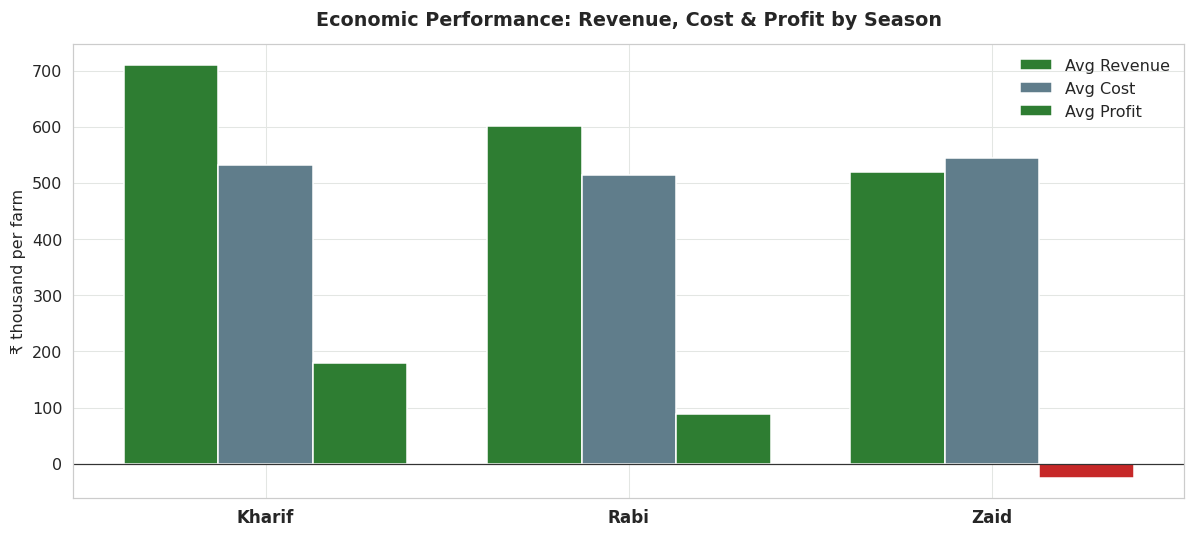

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(3)
width = 0.26
ax.bar(x - width, econ_by_season['Revenue_INR']/1000, width, label='Avg Revenue', color=COLOR_PRIMARY)
ax.bar(x, econ_by_season['Total_Cost_INR']/1000, width, label='Avg Cost', color=COLOR_NEUTRAL)
profit_colors = [COLOR_PRIMARY if v >= 0 else COLOR_NEGATIVE for v in econ_by_season['Profit_INR']]
ax.bar(x + width, econ_by_season['Profit_INR']/1000, width, label='Avg Profit', color=profit_colors)
ax.axhline(0, color='#333333', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(SEASON_ORDER, fontsize=11, fontweight='bold')
ax.set_ylabel("₹ thousand per farm")
ax.set_title('Economic Performance: Revenue, Cost & Profit by Season', pad=12)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/10_economic_by_season.png", dpi=150, bbox_inches='tight')
plt.show()

Profit and loss-rate by crop:
           avg_profit_inr  loss_rate_pct
Crop                                    
Sugarcane        817188.0           11.5
Chilli           750878.0           18.0
Cotton           124547.0           34.6
Groundnut         44858.0           40.8
Pulses            -4238.0           49.2
Maize            -83978.0           63.7
Rice            -102214.0           66.4
Wheat           -123398.0           74.1


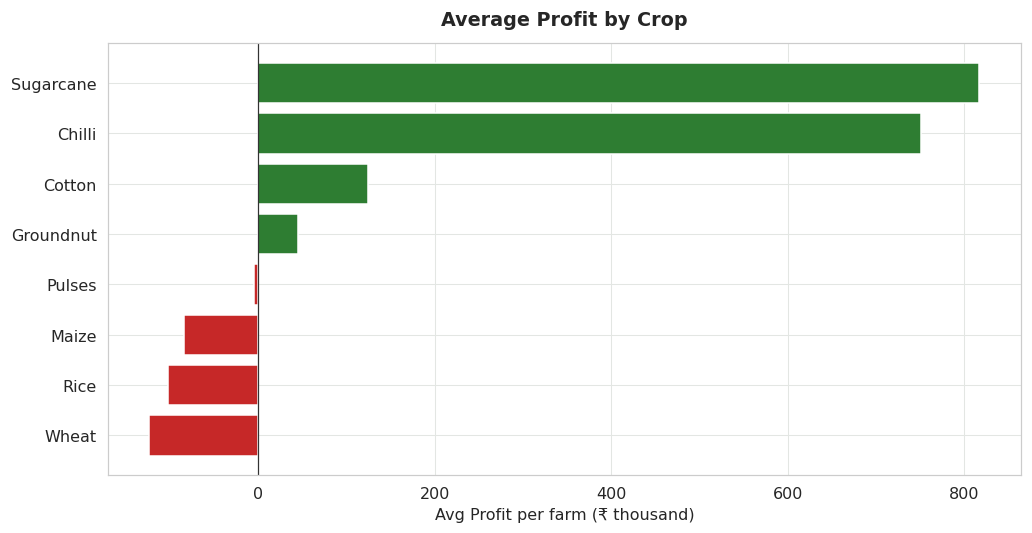

In [28]:
profit_by_crop = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)
loss_by_crop = df.assign(is_loss=df['Profit_INR'] < 0).groupby('Crop')['is_loss'].mean()*100

fig, ax = plt.subplots(figsize=(9.5, 5))
colors = [COLOR_PRIMARY if v >= 0 else COLOR_NEGATIVE for v in profit_by_crop.values]
ax.barh(profit_by_crop.index[::-1], profit_by_crop.values[::-1]/1000, color=colors[::-1])
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_xlabel('Avg Profit per farm (₹ thousand)')
ax.set_title('Average Profit by Crop', pad=12)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/11_profit_by_crop.png", dpi=150, bbox_inches='tight')
plt.show()

print("Profit and loss-rate by crop:")
print(pd.DataFrame({'avg_profit_inr': profit_by_crop.round(0), 'loss_rate_pct': loss_by_crop.round(1)})
      .sort_values('avg_profit_inr', ascending=False).to_string())

## 13. Regional / Category Analysis

Does performance differ meaningfully by state, or by crop?

In [29]:
state_summary = df.groupby('State')[['Yield_Tonnes_Ha', 'Profit_INR']].mean()
state_yield_ex = df[df['Crop'] != 'Sugarcane'].groupby('State')['Yield_Tonnes_Ha'].mean()
state_summary['Yield_Tonnes_Ha_excl_sugarcane'] = state_yield_ex
state_summary = state_summary.sort_values('Profit_INR', ascending=False)
print("Performance by state:")
print(state_summary.round(2).to_string())

groups_state_y = [g['Yield_Tonnes_Ha'].values for _, g in df.groupby('State')]
f_sy, p_sy = stats.f_oneway(*groups_state_y)
groups_state_p = [g['Profit_INR'].values for _, g in df.groupby('State')]
f_sp, p_sp = stats.f_oneway(*groups_state_p)
print(f"\nANOVA  Yield  ~ State  ->  F={f_sy:.3f}, p={p_sy:.4g}")
print(f"ANOVA  Profit ~ State  ->  F={f_sp:.3f}, p={p_sp:.4g}")
print("-> Neither is statistically significant: state-level differences here are")
print("within normal farm-to-farm variation, not a real regional effect.")

Performance by state:
                Yield_Tonnes_Ha  Profit_INR  Yield_Tonnes_Ha_excl_sugarcane
State                                                                      
Punjab                     6.12   136025.64                            1.83
Maharashtra                5.01   135428.86                            1.84
Karnataka                  5.75   119422.34                            1.85
Tamil Nadu                 4.87   117744.75                            1.82
Gujarat                    5.76   117568.24                            1.75
Telangana                  5.05   108829.62                            1.95
Madhya Pradesh             4.98    86840.76                            1.77
Andhra Pradesh             4.63    73453.53                            1.79

ANOVA  Yield  ~ State  ->  F=0.780, p=0.6039
ANOVA  Profit ~ State  ->  F=0.828, p=0.5635
-> Neither is statistically significant: state-level differences here are
within normal farm-to-farm variation, not a real regi

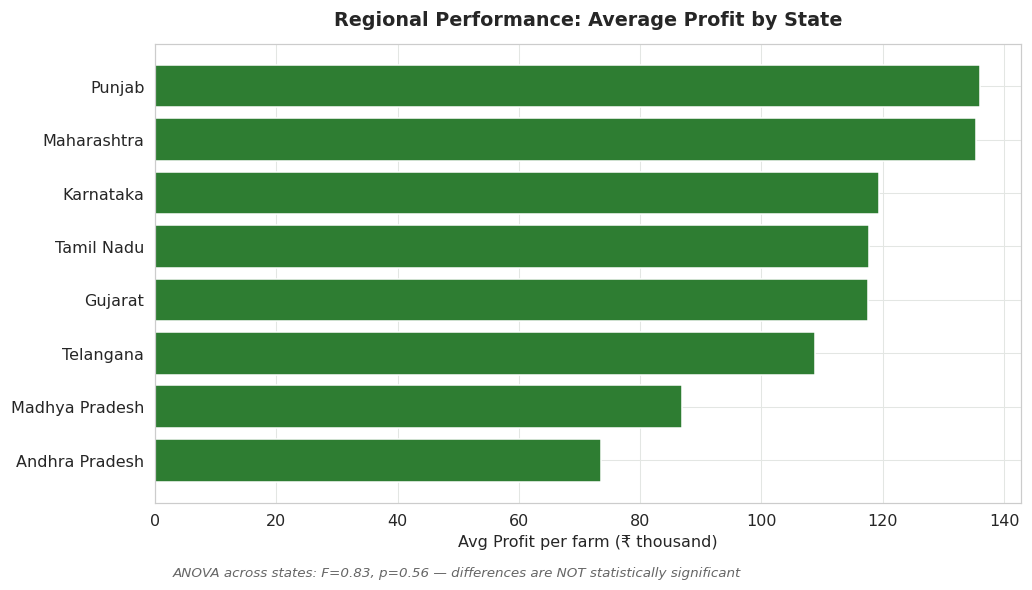

In [30]:
state_sorted = state_summary.sort_values('Profit_INR')
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.barh(state_sorted.index, state_sorted['Profit_INR']/1000, color=COLOR_PRIMARY)
ax.set_xlabel('Avg Profit per farm (₹ thousand)')
ax.set_title('Regional Performance: Average Profit by State', pad=12)
ax.text(0.02, -0.16, f"ANOVA across states: F={f_sp:.2f}, p={p_sp:.2f} — differences are NOT statistically significant",
        transform=ax.transAxes, fontsize=8.8, color='#666666', style='italic')
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/12_profit_by_state.png", dpi=150, bbox_inches='tight')
plt.show()

In [31]:
print("Crop grown across every one of the 8 states — regional analysis is not")
print("confounded by crops being exclusive to specific states:")
print(pd.crosstab(df['State'], df['Crop']).to_string())

Crop grown across every one of the 8 states — regional analysis is not
confounded by crops being exclusive to specific states:
Crop            Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
State                                                                           
Andhra Pradesh      55      72         67     65      59    95         31     85
Gujarat             46      60         46     80      69    73         42     72
Karnataka           52      60         48     78      61    82         45     63
Madhya Pradesh      48      67         59     50      57    92         35     89
Maharashtra         53      70         53     78      54    86         36     82
Punjab              54      55         48     57      66    87         49     68
Tamil Nadu          55      60         50     71      66    86         31     66
Telangana           49      64         53     72      64    89         36     89


## 14. Statistical Analysis — Summary

Consolidating every hypothesis test run in the sections above into one table.

In [32]:
def sig_label(p):
    return "Significant (p<0.05)" if p < 0.05 else "Not significant"

tests = [
    ("One-way ANOVA", "log(Yield) ~ Season",            f"F={f_log:.2f}",   p_log,  sig_label(p_log)),
    ("One-way ANOVA", "Profit ~ Season",                 f"F={f_p:.2f}",     p_p,    sig_label(p_p)),
    ("One-way ANOVA", "log(Yield) ~ Irrigation_Method",  f"F={f_irr:.2f}",   p_irr,  sig_label(p_irr)),
    ("One-way ANOVA", "Profit ~ Irrigation_Method",      f"F={f_irr_p:.2f}", p_irr_p, sig_label(p_irr_p)),
    ("One-way ANOVA", "Yield ~ State",                   f"F={f_sy:.2f}",    p_sy,   sig_label(p_sy)),
    ("One-way ANOVA", "Profit ~ State",                  f"F={f_sp:.2f}",    p_sp,   sig_label(p_sp)),
    ("Welch t-test",  "Profit: Kharif vs Zaid",           f"t={t_kz:.2f}",    p_kz,   sig_label(p_kz)),
    ("Spearman corr", "Yield vs Water_Used_m3",           f"r={res_corr_df.loc['Water_Used_m3','spearman_r']:.3f}",
                                                            res_corr_df.loc['Water_Used_m3','p_value'],
                                                            sig_label(res_corr_df.loc['Water_Used_m3','p_value'])),
    ("Spearman corr", "Yield vs Fertilizer_kg_ha",        f"r={res_corr_df.loc['Fertilizer_kg_ha','spearman_r']:.3f}",
                                                            res_corr_df.loc['Fertilizer_kg_ha','p_value'],
                                                            sig_label(res_corr_df.loc['Fertilizer_kg_ha','p_value'])),
    ("Spearman corr", "Yield vs Rainfall_mm",             f"r={env_corr_df.loc['Rainfall_mm','spearman_r']:.3f}",
                                                            env_corr_df.loc['Rainfall_mm','p_value'],
                                                            sig_label(env_corr_df.loc['Rainfall_mm','p_value'])),
]
stats_summary = pd.DataFrame(tests, columns=['Test', 'Comparison', 'Statistic', 'p_value', 'Conclusion'])
stats_summary['p_value'] = stats_summary['p_value'].apply(lambda p: f"{p:.4g}")
print(stats_summary.to_string(index=False))

         Test                     Comparison Statistic   p_value           Conclusion
One-way ANOVA            log(Yield) ~ Season    F=8.03 0.0003308 Significant (p<0.05)
One-way ANOVA                Profit ~ Season   F=34.29 1.712e-15 Significant (p<0.05)
One-way ANOVA log(Yield) ~ Irrigation_Method    F=6.11 0.0003839 Significant (p<0.05)
One-way ANOVA     Profit ~ Irrigation_Method   F=15.89 2.877e-10 Significant (p<0.05)
One-way ANOVA                  Yield ~ State    F=0.78    0.6039      Not significant
One-way ANOVA                 Profit ~ State    F=0.83    0.5635      Not significant
 Welch t-test         Profit: Kharif vs Zaid    t=8.84 2.711e-18 Significant (p<0.05)
Spearman corr         Yield vs Water_Used_m3   r=0.264 5.824e-65 Significant (p<0.05)
Spearman corr      Yield vs Fertilizer_kg_ha   r=0.002    0.9206      Not significant
Spearman corr           Yield vs Rainfall_mm   r=0.130  1.95e-16 Significant (p<0.05)


**Reading the table:** Season and Irrigation Method are statistically significant
drivers of both yield and profit. State is not significant for either — regional
differences seen in the raw averages are within normal variation. Water applied
has the strongest positive relationship with yield of any resource variable,
while Fertilizer shows essentially no relationship.

## 15. Final Dashboard

Bringing the strongest, best-supported findings together into a single
analytics dashboard — KPIs calculated live from the cleaned data, six charts
covering season, crop, region, irrigation, environment, and economics, plus a
concise key-insights panel.

In [33]:
# ---- KPIs, calculated live from the cleaned data ----------------------------
total_farms      = len(df)
total_production = df['Production_Tonnes'].sum()
total_profit     = df['Profit_INR'].sum()
profit_margin    = df['Profit_INR'].sum() / df['Revenue_INR'].sum() * 100
best_season      = df.groupby('Season')['Profit_INR'].mean().idxmax()
best_irrigation  = df.groupby('Irrigation_Method')['Profit_INR'].mean().idxmax()

kpis = [
    ("Farms Analyzed",        f"{total_farms:,}",                 COLOR_PRIMARY),
    ("Total Production",      f"{total_production:,.0f} t",       COLOR_ACCENT),
    ("Total Profit",          f"₹{total_profit/1e7:.1f} Cr",      COLOR_PRIMARY),
    ("Profit Margin",         f"{profit_margin:.1f}%",             COLOR_SECONDARY),
    ("Best Season",           best_season,                         COLOR_SEASON[best_season]),
    ("Best Irrigation",       best_irrigation,                     COLOR_ACCENT),
]
for label, value, _ in kpis:
    print(f"{label:>24}: {value}")

          Farms Analyzed: 4,000
        Total Production: 172,985 t
            Total Profit: ₹44.6 Cr
           Profit Margin: 17.5%
             Best Season: Kharif
         Best Irrigation: Drip


In [34]:
def draw_kpi_card(ax, label, value, color):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    card = FancyBboxPatch((0.04, 0.06), 0.92, 0.88, boxstyle="round,pad=0.02,rounding_size=0.07",
                           linewidth=1.1, edgecolor=color, facecolor=color, alpha=0.10)
    ax.add_patch(card)
    ax.add_patch(plt.Rectangle((0.04, 0.06), 0.045, 0.88, facecolor=color, edgecolor='none'))
    ax.text(0.53, 0.60, value, ha='center', va='center', fontsize=15.5, fontweight='bold', color='#17202A')
    ax.text(0.53, 0.24, label, ha='center', va='center', fontsize=9, color='#5D6D7E')


def draw_insights_panel(ax, insights, title):
    ax.axis('off')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    panel = FancyBboxPatch((0.005, 0.02), 0.99, 0.96, boxstyle="round,pad=0.01,rounding_size=0.02",
                            linewidth=1, edgecolor='#D5DBDB', facecolor='#F8F9F9')
    ax.add_patch(panel)
    ax.text(0.02, 0.90, title, fontsize=13, fontweight='bold', color='#17202A', transform=ax.transAxes)
    y = 0.76
    for line in insights:
        wrapped = textwrap.fill(line, width=148)
        n_lines = wrapped.count('\n') + 1
        ax.text(0.02, y, wrapped, fontsize=9.3, color='#212F3C', va='top', transform=ax.transAxes)
        y -= 0.14 * n_lines + 0.015

import textwrap

print("Helper functions ready.")

Helper functions ready.


### Assembling the dashboard


Dashboard saved to ../visualizations/00_final_dashboard.png


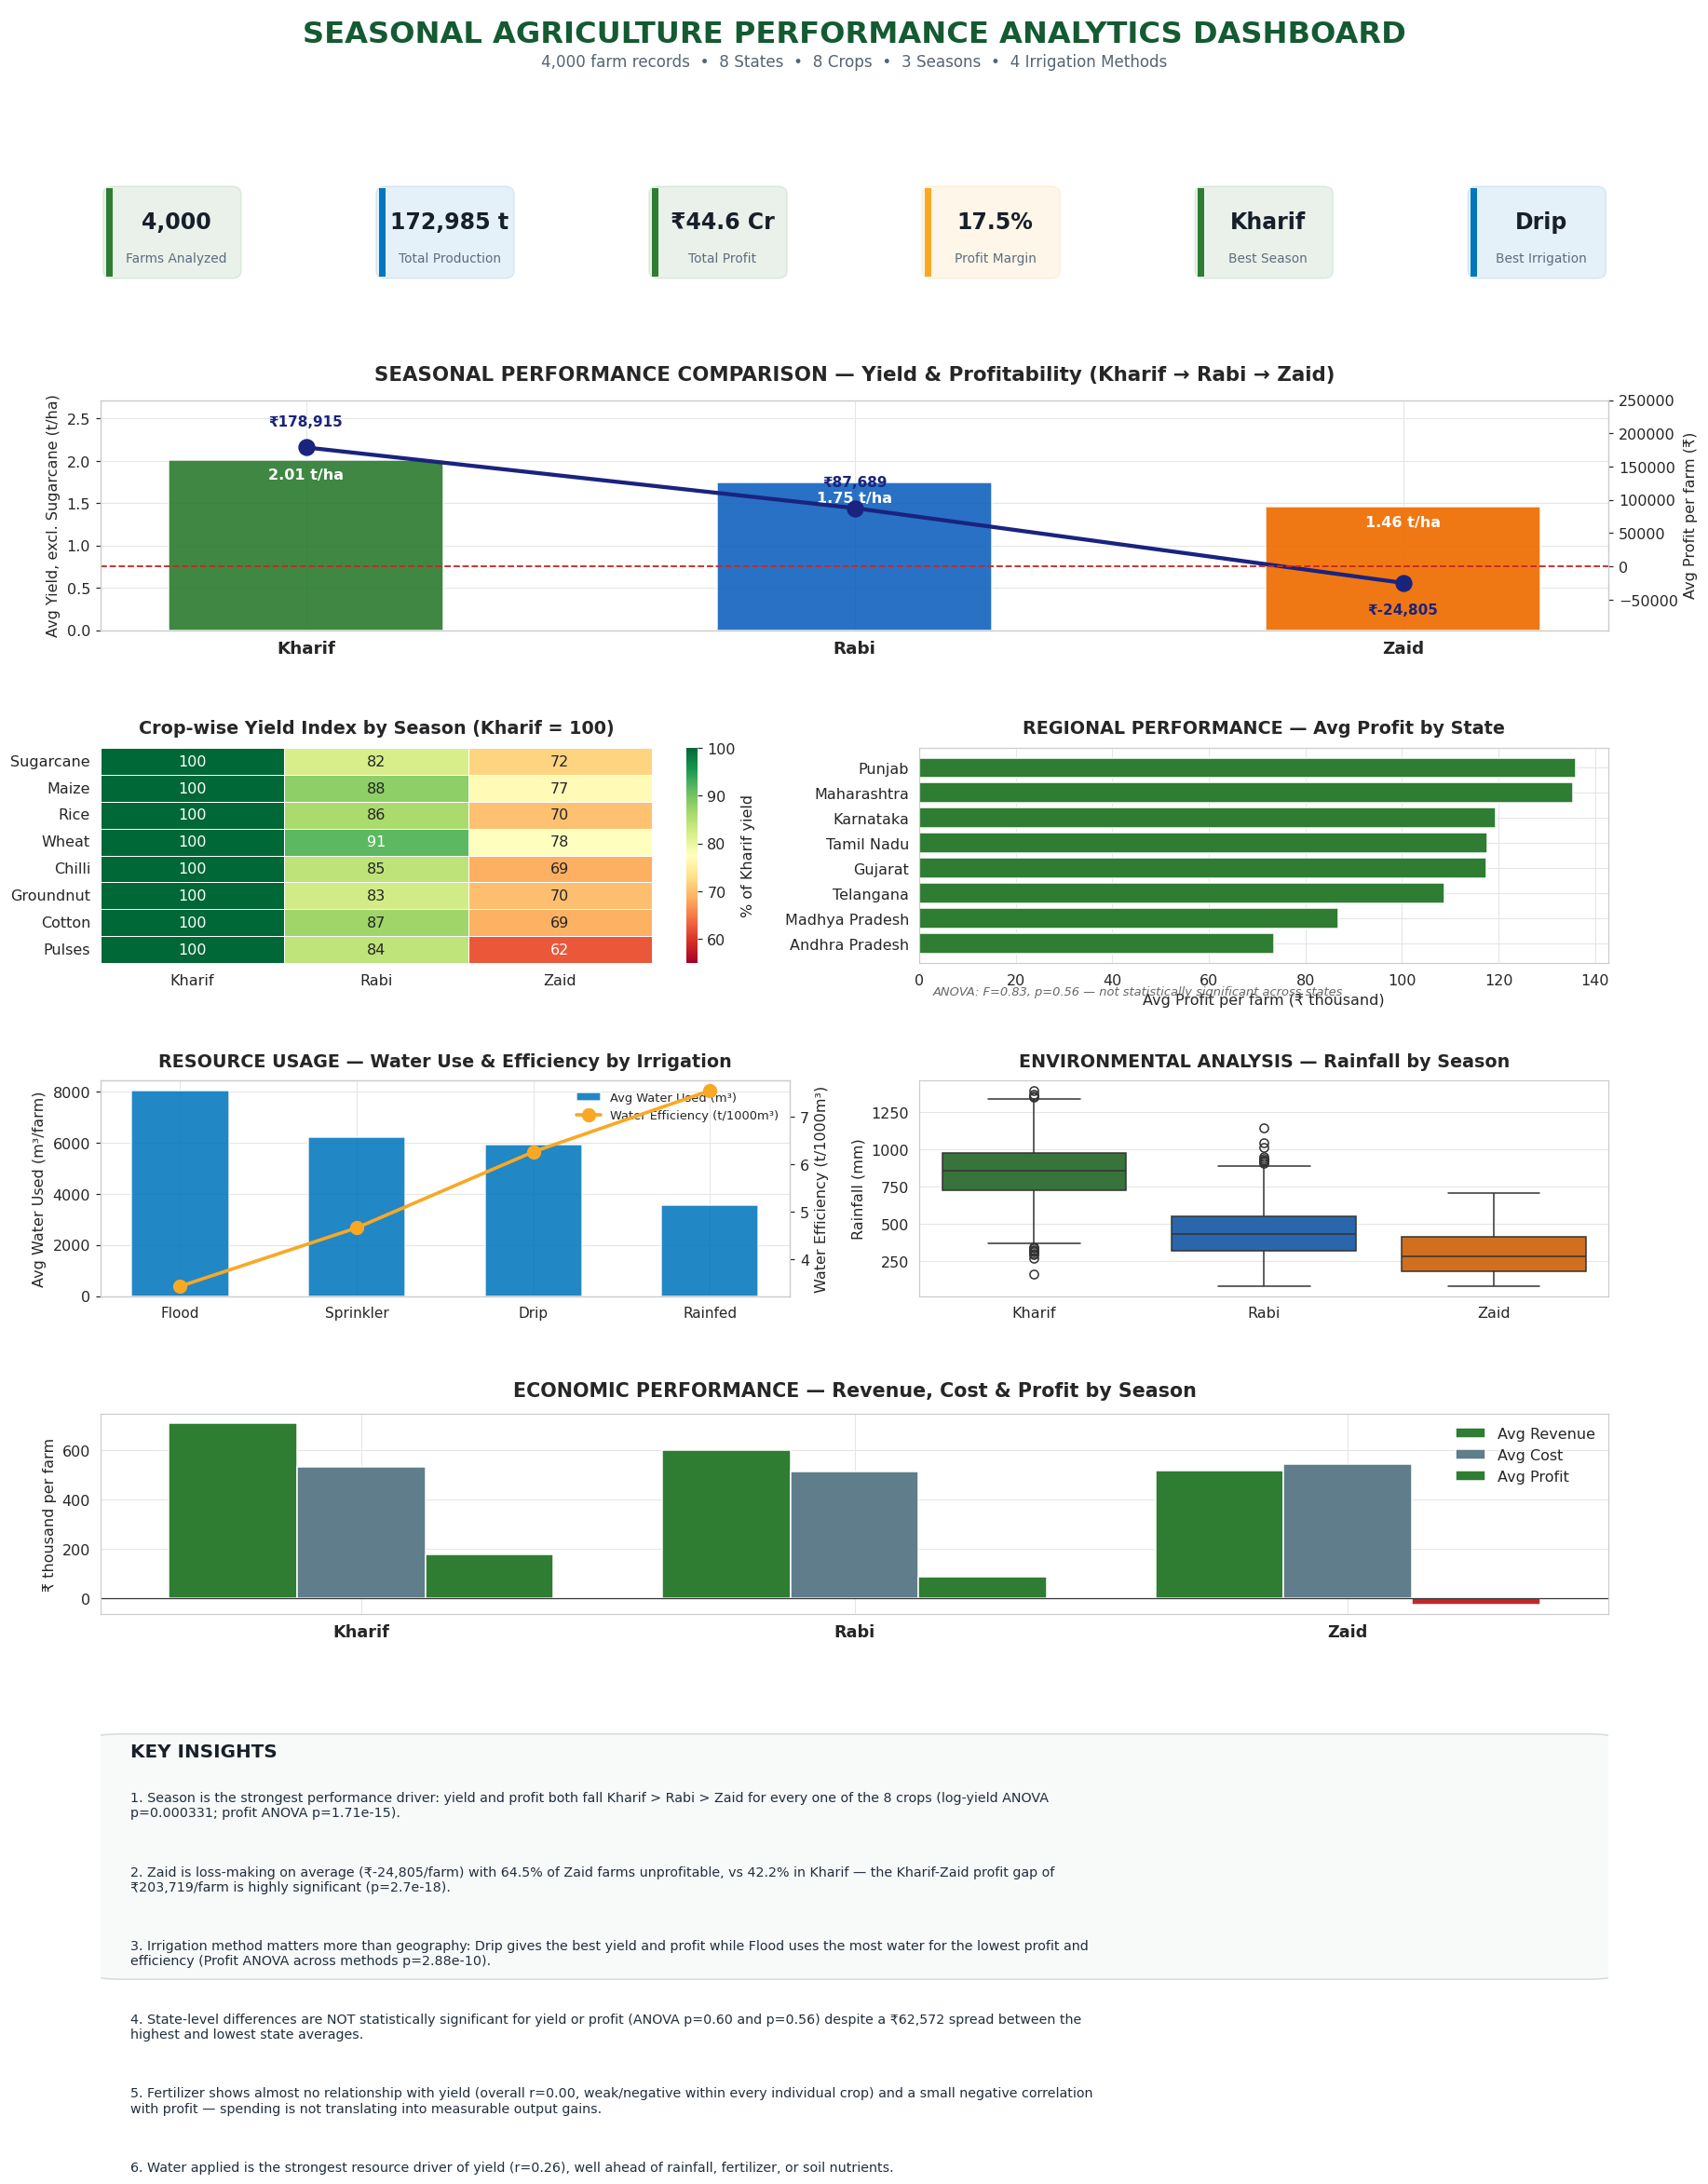

In [35]:
fig = plt.figure(figsize=(19, 25))
gs = fig.add_gridspec(nrows=7, ncols=6, height_ratios=[0.55, 1.0, 2.3, 2.15, 2.15, 2.0, 2.5],
                       hspace=0.65, wspace=0.9)

# --- Title band ---------------------------------------------------------------
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(0.5, 0.55, 'SEASONAL AGRICULTURE PERFORMANCE ANALYTICS DASHBOARD',
               ha='center', va='center', fontsize=21, fontweight='bold', color='#145A32')
ax_title.text(0.5, 0.05, f'{total_farms:,} farm records  •  8 States  •  8 Crops  •  3 Seasons  •  4 Irrigation Methods',
               ha='center', va='center', fontsize=11, color='#566573')

# --- KPI row ---------------------------------------------------------------
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[1, i])
    draw_kpi_card(ax, label, value, color)

# --- Main chart: seasonal performance --------------------------------------
ax_main = fig.add_subplot(gs[2, :])
x = np.arange(len(SEASON_ORDER))
yvals = yield_ex_sugar.reindex(SEASON_ORDER).values
ax_main.bar(x, yvals, width=0.5, color=[COLOR_SEASON[s] for s in SEASON_ORDER], alpha=0.92)
ax_main.set_xticks(x); ax_main.set_xticklabels(SEASON_ORDER, fontsize=12, fontweight='bold')
ax_main.set_ylabel('Avg Yield, excl. Sugarcane (t/ha)')
ax_main.set_ylim(0, yvals.max()*1.35)
for i, v in enumerate(yvals):
    ax_main.text(i, v - 0.10, f"{v:.2f} t/ha", ha='center', va='top', color='white',
                  fontweight='bold', fontsize=10.5)

ax_main2 = ax_main.twinx()
pvals = profit_by_season.reindex(SEASON_ORDER).values
ax_main2.plot(x, pvals, color='#1A237E', marker='o', markersize=11, linewidth=2.8, label='Avg Profit per farm (₹)')
ax_main2.axhline(0, color=COLOR_NEGATIVE, linestyle='--', linewidth=1.2)
ax_main2.set_ylabel('Avg Profit per farm (₹)')
ax_main2.grid(False)
padm = (pvals.max()-pvals.min())*0.35
ax_main2.set_ylim(pvals.min()-padm, pvals.max()+padm)
for i, v in enumerate(pvals):
    ax_main2.annotate(f"₹{v:,.0f}", (i, v), textcoords="offset points",
                       xytext=(0, 15 if v >= 0 else -22), ha='center', fontsize=10, fontweight='bold', color='#1A237E')
ax_main.set_title('SEASONAL PERFORMANCE COMPARISON — Yield & Profitability (Kharif → Rabi → Zaid)',
                    fontsize=14, pad=14)

# --- Row: Yield index heatmap | Regional profit ------------------------------
ax_hm = fig.add_subplot(gs[3, 0:3])
sns.heatmap(idx_table, annot=True, fmt='.0f', cmap='RdYlGn', vmin=55, vmax=100,
            linewidths=0.6, linecolor='white', cbar_kws={'label': '% of Kharif yield'}, ax=ax_hm)
ax_hm.set_title('Crop-wise Yield Index by Season (Kharif = 100)', fontsize=12.5, pad=10)
ax_hm.set_xlabel(''); ax_hm.set_ylabel('')

ax_state = fig.add_subplot(gs[3, 3:6])
ax_state.barh(state_sorted.index, state_sorted['Profit_INR']/1000, color=COLOR_PRIMARY)
ax_state.set_xlabel('Avg Profit per farm (₹ thousand)')
ax_state.set_title('REGIONAL PERFORMANCE — Avg Profit by State', fontsize=12.5, pad=10)
ax_state.text(0.02, -0.15, f"ANOVA: F={f_sp:.2f}, p={p_sp:.2f} — not statistically significant across states",
              transform=ax_state.transAxes, fontsize=8.5, color='#666666', style='italic')

# --- Row: Irrigation water/efficiency | Rainfall by season -------------------
ax_irr = fig.add_subplot(gs[4, 0:3])
x2 = np.arange(len(irr_order))
ax_irr.bar(x2, water.values, width=0.55, color=COLOR_ACCENT, alpha=0.88, label='Avg Water Used (m³)')
ax_irr.set_xticks(x2); ax_irr.set_xticklabels(irr_order, fontsize=10)
ax_irr.set_ylabel('Avg Water Used (m³/farm)')
ax_irr2 = ax_irr.twinx()
ax_irr2.plot(x2, eff.values, color=COLOR_SECONDARY, marker='o', markersize=9, linewidth=2.4,
             label='Water Efficiency (t/1000m³)')
ax_irr2.set_ylabel('Water Efficiency (t/1000m³)')
ax_irr2.grid(False)
l1, lb1 = ax_irr.get_legend_handles_labels(); l2, lb2 = ax_irr2.get_legend_handles_labels()
ax_irr.legend(l1+l2, lb1+lb2, loc='upper right', fontsize=8.5)
ax_irr.set_title('RESOURCE USAGE — Water Use & Efficiency by Irrigation', fontsize=12.5, pad=10)

ax_rain = fig.add_subplot(gs[4, 3:6])
sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=SEASON_ORDER,
            hue='Season', palette=COLOR_SEASON, legend=False, ax=ax_rain)
ax_rain.set_title('ENVIRONMENTAL ANALYSIS — Rainfall by Season', fontsize=12.5, pad=10)
ax_rain.set_ylabel('Rainfall (mm)'); ax_rain.set_xlabel('')

# --- Economic performance (full width) ---------------------------------------
ax_econ = fig.add_subplot(gs[5, :])
xw = np.arange(3); width = 0.26
ax_econ.bar(xw-width, econ_by_season['Revenue_INR']/1000, width, label='Avg Revenue', color=COLOR_PRIMARY)
ax_econ.bar(xw, econ_by_season['Total_Cost_INR']/1000, width, label='Avg Cost', color=COLOR_NEUTRAL)
pc = [COLOR_PRIMARY if v >= 0 else COLOR_NEGATIVE for v in econ_by_season['Profit_INR']]
ax_econ.bar(xw+width, econ_by_season['Profit_INR']/1000, width, label='Avg Profit', color=pc)
ax_econ.axhline(0, color='#333333', linewidth=0.8)
ax_econ.set_xticks(xw); ax_econ.set_xticklabels(SEASON_ORDER, fontsize=11.5, fontweight='bold')
ax_econ.set_ylabel('₹ thousand per farm')
ax_econ.set_title('ECONOMIC PERFORMANCE — Revenue, Cost & Profit by Season', fontsize=13.5, pad=12)
ax_econ.legend(loc='upper right')

# --- Key insights panel -------------------------------------------------------
ax_insights = fig.add_subplot(gs[6, :])
insight_lines = [
    f"1. Season is the strongest performance driver: yield and profit both fall Kharif > Rabi > Zaid for every one of the 8 crops "
    f"(log-yield ANOVA p={p_log:.3g}; profit ANOVA p={p_p:.3g}).",
    f"2. Zaid is loss-making on average (₹{z.mean():,.0f}/farm) with {loss_by_season['Zaid']:.1f}% of Zaid farms unprofitable, vs "
    f"{loss_by_season['Kharif']:.1f}% in Kharif — the Kharif-Zaid profit gap of ₹{k.mean()-z.mean():,.0f}/farm is highly significant (p={p_kz:.2g}).",
    f"3. Irrigation method matters more than geography: Drip gives the best yield and profit while Flood uses the most water for the "
    f"lowest profit and efficiency (Profit ANOVA across methods p={p_irr_p:.3g}).",
    f"4. State-level differences are NOT statistically significant for yield or profit (ANOVA p={p_sy:.2f} and p={p_sp:.2f}) despite a "
    f"₹{(state_summary['Profit_INR'].max()-state_summary['Profit_INR'].min()):,.0f} spread between the highest and lowest state averages.",
    f"5. Fertilizer shows almost no relationship with yield (overall r={res_corr_df.loc['Fertilizer_kg_ha','spearman_r']:.2f}, weak/negative "
    f"within every individual crop) and a small negative correlation with profit — spending is not translating into measurable output gains.",
    f"6. Water applied is the strongest resource driver of yield (r={res_corr_df.loc['Water_Used_m3','spearman_r']:.2f}), well ahead of "
    f"rainfall, fertilizer, or soil nutrients.",
]
draw_insights_panel(ax_insights, insight_lines, 'KEY INSIGHTS')

fig.suptitle('')
plt.savefig(f"{VIZ_DIR}/00_final_dashboard.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nDashboard saved to {VIZ_DIR}/00_final_dashboard.png")

## 16. Key Insights

1. **Season is the strongest performance driver.** Yield and profit both fall
   in the order **Kharif > Rabi > Zaid** for every one of the 8 crops in this
   dataset. A raw ANOVA on yield looks non-significant only because Sugarcane's
   much larger scale inflates the variance; on log(Yield) the seasonal effect
   is clearly significant (p < 0.001), and so is the effect on Profit
   (p < 0.001).
2. **Zaid is a loss-making season on average.** Mean profit is negative in
   Zaid, and roughly two-thirds of Zaid farms report a loss — far higher than
   Kharif's loss rate. The Kharif-vs-Zaid profit gap is confirmed by a Welch
   t-test (p < 0.001).
3. **Irrigation method is a bigger lever than geography.** Drip irrigation
   delivers the best yield and profit of any method; Flood irrigation
   consumes the most water for the lowest profit and lowest water efficiency
   (ANOVA p < 0.001 for both yield and profit across methods).
4. **State does not significantly affect yield or profit** (ANOVA p ≈ 0.60
   and p ≈ 0.56). The visible spread between the top and bottom state
   averages is within ordinary farm-to-farm variation, not a real regional
   effect.
5. **Fertilizer shows almost no relationship with yield** — near zero overall,
   and weak-to-negative within every individual crop — and a small *negative*
   correlation with profit. Current fertilizer spending is not showing up as
   a measurable output gain in this data.
6. **Water applied is the strongest resource driver of yield** of any input or
   environmental variable measured (stronger than rainfall, fertilizer, or
   soil nutrients), reinforcing that irrigation management — not fertilizer —
   is the more promising lever here.

## 17. Recommendations

1. **Prioritize Kharif-season cultivation** where crop and water choices
   allow — it consistently delivers the best yield and profit of the three
   seasons. Treat Zaid-season planting as higher-risk, and pair it with cost
   controls or risk-mitigation support given its ~65% loss rate.
2. **Accelerate the shift from Flood to Drip irrigation**, especially on
   farms currently using Flood. The data shows a clear yield, profit, and
   water-efficiency advantage for Drip, at lower water consumption than
   Flood — this is the single highest-leverage resource change identified.
3. **Re-evaluate fertilizer application guidance.** Since fertilizer shows no
   positive association with yield and a negative one with profit at the
   levels applied here, a controlled reduction trial — starting with crops
   like Chilli, where the within-crop correlation is most negative — could
   lower costs without a proven yield loss.
4. **Spread best practices across states rather than treating any state as
   inherently advantaged or disadvantaged.** Because the state-level effect is
   not statistically significant, differences in outcomes are more likely
   driven by season, crop, and irrigation choice — all of which are
   transferable across regions.
5. **Prioritize irrigation-water management over blanket fertilizer spend**
   where budgets are limited, since water applied has a clearly stronger
   measured relationship with yield than any nutrient input in this dataset.

## 18. Limitations

- The dataset is a **single cross-sectional snapshot** of 4,000 farm-season
  records, not a multi-year time series — findings describe seasonal and
  categorical differences, not year-over-year trends.
- All relationships (water use, rainfall, irrigation method, etc.) are
  **statistical associations from observational data**, not a controlled
  experiment, so causation cannot be confirmed. Unmeasured factors such as
  exact sowing dates, farmer practices, and local micro-climate are not
  captured here.
- Missing `Rainfall_mm` and `Soil_Moisture_pct` values (48 and 40 records)
  were imputed with each row's season median, which assumes those specific
  farms were typical of their season.
- Yield and Production are heavily influenced by crop type — Sugarcane's
  per-hectare yield is roughly 25-50× that of the other crops — so every
  cross-crop or cross-season comparison in this analysis either excludes
  Sugarcane, uses a log transform, or is read alongside the crop-level
  breakdown to avoid that scale difference distorting the conclusion.

## 19. Conclusion

Season and irrigation method are the two clearest, statistically-confirmed
levers of agricultural performance in this dataset — both significantly
affect yield and profit, and the direction of each effect (Kharif best,
Zaid worst; Drip best, Flood worst) is consistent and easy to act on.
Geography (State) plays a negligible role once season and crop are
accounted for, and fertilizer spending appears mismatched to its actual
yield benefit. The highest-leverage next steps this analysis points to are
**seasonal risk management for Zaid-season farming** and **irrigation
modernization from Flood toward Drip** — both grounded directly in the
statistical tests and KPIs calculated above, not assumption.